<a href="https://colab.research.google.com/github/Ragul2526/stable-diffusion-anime-finetune-lora/blob/main/anime_lora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install diffusers transformers accelerate datasets peft -q

In [3]:
#These are the libraries needed for the fine tuning of the anime dataset
import torch
import numpy as np
from datasets import load_dataset
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel
from peft import LoraConfig, get_peft_model
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
#Check if gpu available or not go to view resources and change to T4 GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU: Tesla T4


In [5]:
#It will take about 15 to 30 minutes to download based on the internet speed.
dataset = load_dataset("huggan/anime-faces", split="train", streaming=True)
dataset = dataset.take(5000)
print("Dataset ready!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/huggan/anime-faces/resolve/67ebcf8c69b45feb3883d695f04227078a6c9da9/anime-faces.py
Rate limited. Waiting 44.0s before retry [Retry 1/5].


Resolving data files:   0%|          | 0/43103 [00:00<?, ?it/s]

Dataset ready!


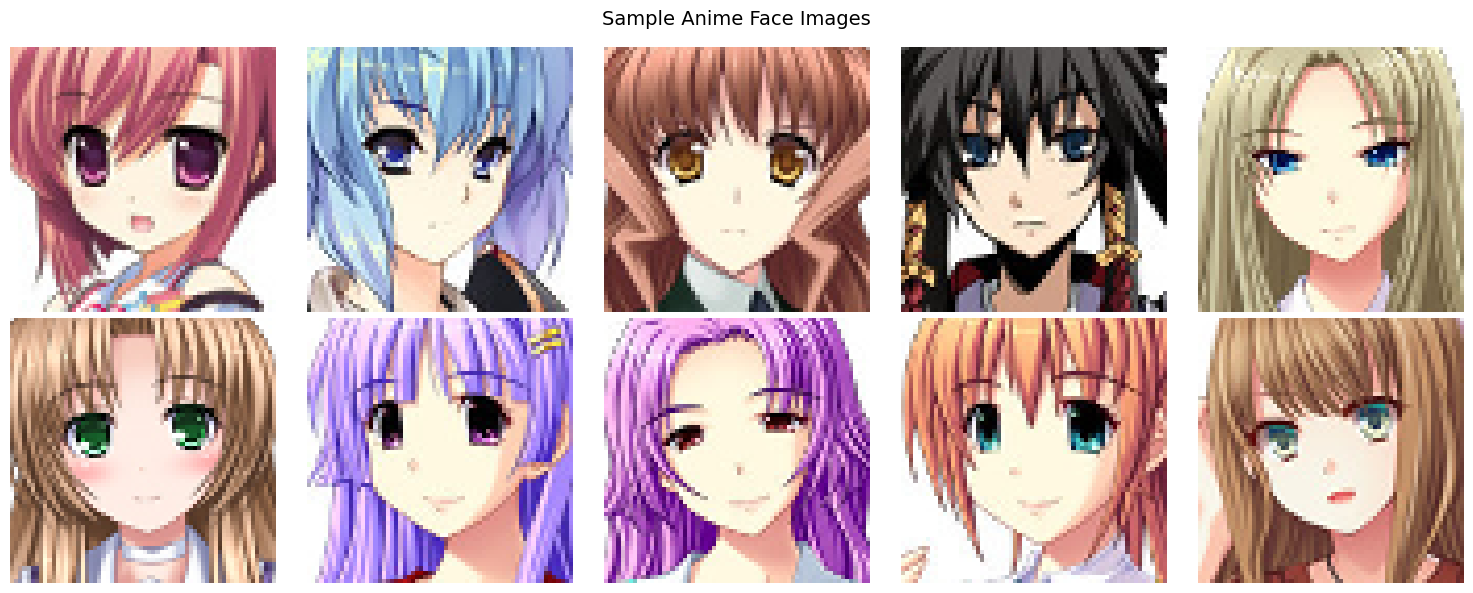

In [7]:
samples = []
for item in dataset.take(10):
    samples.append(item["image"])
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Anime Face Images", fontsize=14)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [19]:
from torch.utils.data import Dataset
from tqdm import tqdm
transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor(), #to convert from [0,255] -> [0,1]
    transforms.Normalize([0.5,0.5,0.5],
                         [0.5,0.5,0.5]) #normalizing the values from [0,1] -> [-1,1]

])
class AnimeDataset(Dataset):
  def __init__(self, hf_dataset, tokenizer, caption = "anime face, high quality, detailed") :

    self.items = []
    self.tokenizer = tokenizer
    self.caption =  caption
    for item in tqdm(hf_dataset, desc="Loading images", unit="img"):
            self.items.append(item["image"])
  def __len__(self):
    return len(self.items)
  def __getitem__(self, idx):
     image = self.data[idx]["image"].convert("RGB")
     image = transform(image)

     token = self.tokenizer(
         self.caption,
         padding = "max_length",
         max_length = self.tokenizer.model_max_length,
         truncation = True,
         return_tensors = "pt"
     )
     return {
         "pixel_values": image,
          "input_ids": token.input_ids.squeeze()
     }



#This will take above 20 minutes so just run and chill for a while 😭

In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
anime_dataset = AnimeDataset(dataset,tokenizer)
dataloader = DataLoader(anime_dataset, batch_size = 2, shuffle = True)
print(f"Total images : {len(anime_dataset)}")
print(f"Total batches: {len(dataloader)}")

batch =  next(iter(dataset))
print(f"Image batch shape: {batch['pixel_values'].shape}")
print(f"Token batch shape : {batch["input_ids"].shape}")

Loading images: 4569img [11:07,  5.92img/s]

In [ ]:
from diffusers import AutoencoderKL
from transformers import CLIPTextModel

print("Loading models...")

vae = AutoencoderKL.from_pretrained(model_id subfolder="vae")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder")
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)

vae = vae.to(device)
text_encoder = text_encoder.to(device)
unet = unet.to(device)

print("Models loaded!")

In [ ]:
lora_config = LoraConfig(
    r=4,                          # rank -> higher = more expressive but slower
    lora_alpha=32,                # scaling factor
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],  # attention layers
    lora_dropout=0.1,
)

unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

In [ ]:
from diffusers import DDPMScheduler
import torch.nn.functional as F

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

NUM_EPOCHS = 3 #why just 3? its enough to see anime style without overfitting  or taking too long in colab

In [ ]:
from tqdm import tqdm

unet.train()

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    progress = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", unit="batch")

    for batch in progress:
        pixel_values = batch["pixel_values"].to(device)
        input_ids    = batch["input_ids"].to(device)


        with torch.no_grad():
            latents      = vae.encode(pixel_values).latent_dist.sample()
            latents      = latents * vae.config.scaling_factor
            text_embeds  = text_encoder(input_ids)[0]


        noise     = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                  (latents.shape[0],), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)


        noise_pred = unet(noisy_latents, timesteps, text_embeds).sample


        loss = F.mse_loss(noise_pred, noise)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1} complete — avg loss: {avg_loss:.4f}")

print("\nTraining complete!")